In [ ]:
# Libraries
library(tidyverse)
library(reshape2)
library(vegan)
library(lme4)

*Load shotgun data and summarize to genus*

In [35]:
# Samples
s <- c('OP0.2A','OP0.2B','OP0.2C','OP1.2A','OP1.2B','OP1.2C','OP5.0A','OP5.0B','OP5.0C','OP8.0A','OP8.0B','OP8.0C', 'EN0.2A','EN0.2B','EN0.2C')

# Data
df <- read.delim("GenomeDK_LCA/counts.lca.rarefy.tsv")

# Check potential issues
df %>% select(superkingdom, genus) %>% unique() %>% group_by(genus) %>% count() %>% filter(n > 1)
df %>% filter(genus == "Bacillus") %>% select(superkingdom, genus) %>% unique()

# Correct issue
df <- df %>% mutate(genus = ifelse(superkingdom == 'Eukaryota' & genus == 'Bacillus', 'Bacillus_E', genus))

# Summarize data at the genus level
genus <- df %>% group_by(genus) %>% drop_na(genus) %>% select(s) %>% melt() %>% ungroup() %>% group_by(genus, variable) %>%
 summarise(value = sum(value)) %>% spread(genus, value) %>% rename(sample = variable) %>% as.data.frame()

genus,n
<chr>,<int>
Bacillus,2
NA,5


,superkingdom,genus
,<chr>,<chr>
1,Bacteria,Bacillus
21,Eukaryota,Bacillus


Adding missing grouping variables: `genus`
Using genus as id variables

`summarise()` has grouped output by 'genus'. You can override using the `.groups`
argument.


*PERMANOVA*

In [60]:
# Separate numbers from metadata
data <- genus[,-1]
meta <- data.frame(PoreType = unlist(lapply(s, function(x) gsub("[A-C]", "", x))))

In [62]:
permanova <- adonis2(data ~ PoreType, data = meta, method = "bray", permutations = 999)
permanova

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PoreType,4,2.301097,0.7714468,8.438372,0.002
Residual,10,0.681736,0.2285532,NA,NA
Total,14,2.982833,1.0000000,NA,NA


_Permanova or test of centroids_: The sum of squares shows that most of the variation is explained by the pore type, with a total of 77.14% explained by this variable. There is a 22.85% variation not explained by the pore type. Moreover, the F statistic shows that there is a large difference between pore types (samples) in comparison to within pore types (replicates).

*Beta Dispersion*

In [66]:
# Compute distance matrix
bray_dist <- vegdist(data, method="bray")

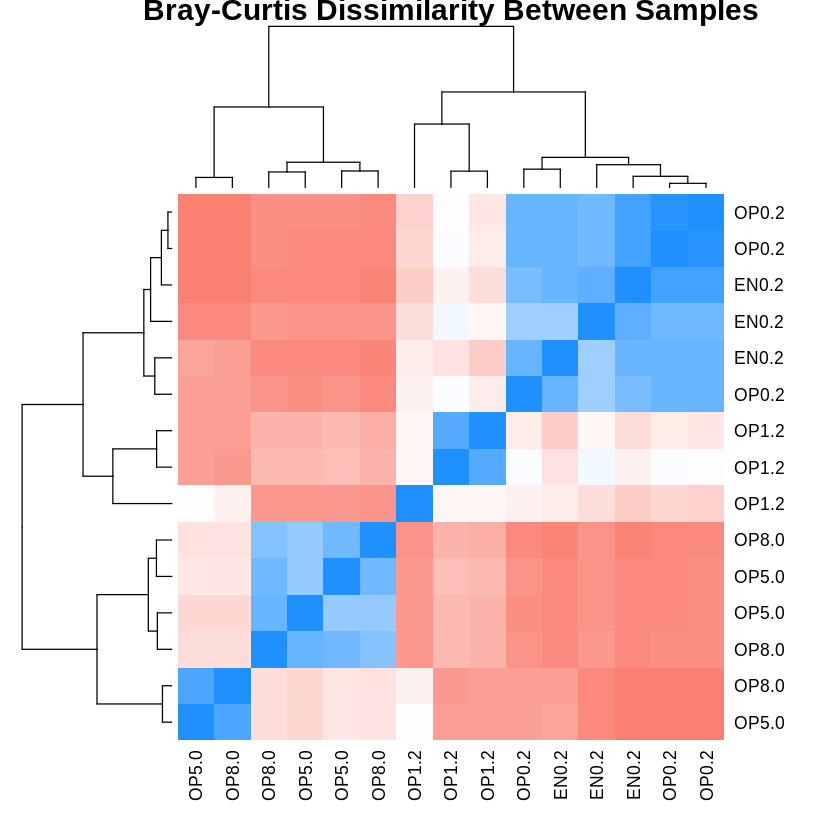

In [104]:
# Visualize distance matrix
distmat <- as.matrix(bray_dist)
ord <- order(meta$PoreType)
distmat <- distmat[ord, ord]
rownames(distmat) <- meta$PoreType[ord]
colnames(distmat) <- meta$PoreType[ord]
heatmap(distmat, scale = "none", col = colorRampPalette(c("dodgerblue", "white", "salmon"))(50), main = "Bray-Curtis Dissimilarity Between Samples")

In [115]:
# Compute dispersion
disp <- betadisper(bray_dist, meta$PoreType, type="median")
disp

Warning message in betadisper(bray_dist, meta$PoreType, type = "median"):
“some squared distances are negative and changed to zero”



	Homogeneity of multivariate dispersions

Call: betadisper(d = bray_dist, group = meta$PoreType, type = "median")

No. of Positive Eigenvalues: 10
No. of Negative Eigenvalues: 4

Average distance to median:
  EN0.2   OP0.2   OP1.2   OP5.0   OP8.0 
0.09581 0.05780 0.19324 0.25652 0.24629 

Eigenvalues for PCoA axes:
(Showing 8 of 14 eigenvalues)
   PCoA1    PCoA2    PCoA3    PCoA4    PCoA5    PCoA6    PCoA7    PCoA8 
1.961921 0.615433 0.345937 0.046257 0.031332 0.016419 0.008258 0.007359 

_Betadisper or replicates dispersion_: The results show low dispersion for EN0.2, OP0.2 or OP1.2 while large dispersion for OP5.0 and OP8.0

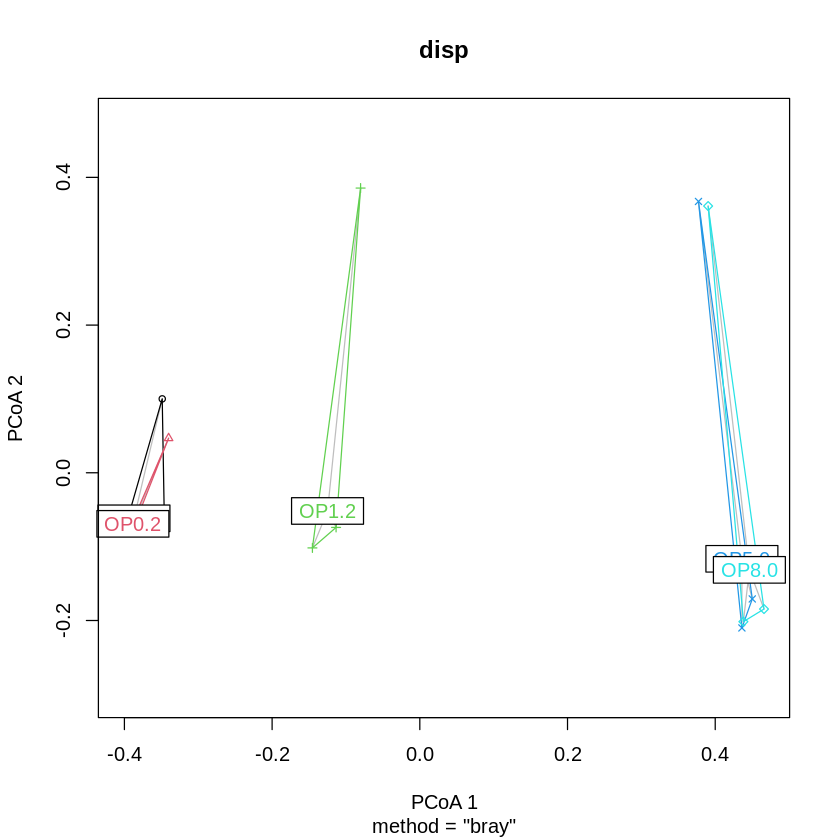

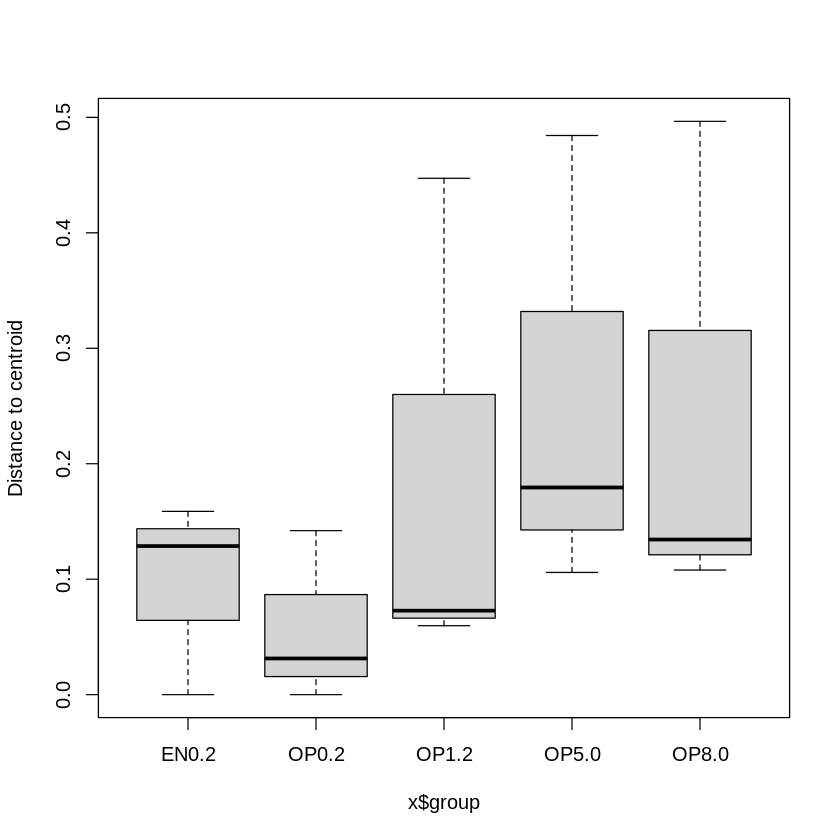

In [116]:
plot(disp)
boxplot(disp)

In [117]:
anova(disp)

,Df,Sum Sq,Mean Sq,F value,Pr(>F)
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Groups,4,0.09581291,0.02395323,0.8064839,0.5484446
Residuals,10,0.29700813,0.02970081,NA,NA


In [119]:
TukeyHSD(disp)

  Tukey multiple comparisons of means
    95% family-wise confidence level

Fit: aov(formula = distances ~ group, data = df)

$group
                   diff        lwr       upr     p adj
OP0.2-EN0.2 -0.03800099 -0.5011036 0.4251017 0.9986207
OP1.2-EN0.2  0.09743007 -0.3656726 0.5605327 0.9536313
OP5.0-EN0.2  0.16071328 -0.3023894 0.6238159 0.7818582
OP8.0-EN0.2  0.15048093 -0.3126217 0.6135836 0.8177896
OP1.2-OP0.2  0.13543106 -0.3276716 0.5985337 0.8657280
OP5.0-OP0.2  0.19871427 -0.2643884 0.6618169 0.6342327
OP8.0-OP0.2  0.18848192 -0.2746207 0.6515846 0.6752601
OP5.0-OP1.2  0.06328321 -0.3998194 0.5263859 0.9902283
OP8.0-OP1.2  0.05305085 -0.4100518 0.5161535 0.9949876
OP8.0-OP5.0 -0.01023235 -0.4733350 0.4528703 0.9999924


However, the p-value of the anova and Tukey's test are largely non-significant. Therefore, the dispersion between groups is not a main driver of the differences in community composition. 

--------------

*PERMANOVA with extra factors*

In [196]:
# Add metadata
meta <- data.frame(
	Replicate = unlist(lapply(s, function(x) str_sub(x, 6))),
	PoreType = unlist(lapply(s, function(x) gsub("[A-C]", "", x))),
	PoreSize = unlist(lapply(s, function(x) str_sub(x, 3, 5))),
	SamplingOrder = c(2,2,2,3,3,3,4,4,4,5,5,5,1,1,1))

In [149]:
adonis2(data ~ PoreType + SamplingOrder,
        data = meta,
        method = "bray",
        permutations = 999,
        strata = meta$Replicate)

,Df,SumOfSqs,R2,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PoreType,4,2.301097,0.7714468,8.438372,0.001
Residual,10,0.681736,0.2285532,NA,NA
Total,14,2.982833,1.0000000,NA,NA


---------------

*Linear Mixed Model using PCoA*

In [173]:
# PCoA from distance matrix: Bray Curtis
pcoa <- cmdscale(bray_dist, eig = TRUE, k = 2)
coords <- as.data.frame(pcoa$points)
colnames(coords) <- c("PCoA1", "PCoA2")

In [197]:
# Add metadata
coords$PoreType <- meta$PoreType
coords$PoreSize <- meta$PoreSize
coords$Replicate <- meta$Replicate
coords$SamplingOrder <- meta$SamplingOrder

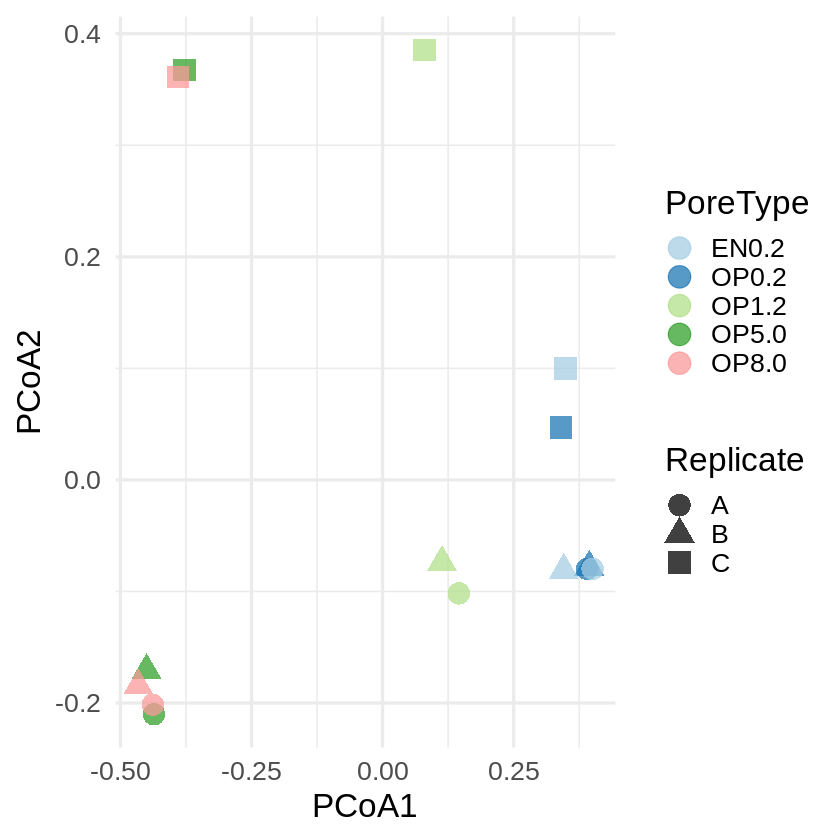

In [198]:
# Visualize PCoA
ggplot(coords, aes(x = PCoA1, y = PCoA2, color = PoreType, shape = Replicate)) +
  geom_point(size = 6, alpha=0.75) +
  theme_minimal(base_size = 20) +
  scale_color_brewer(palette = "Paired")

boundary (singular) fit: see help('isSingular')



Linear mixed model fit by REML ['lmerMod']
Formula: PCoA1 ~ PoreSize + SamplingOrder + (1 | Replicate)
   Data: coords

REML criterion at convergence: -33.6

Scaled residuals: 
    Min      1Q  Median      3Q     Max 
-1.0097 -0.7049 -0.1927  0.7562  1.2800 

Random effects:
 Groups    Name        Variance  Std.Dev. 
 Replicate (Intercept) 1.380e-25 3.714e-13
 Residual              1.175e-03 3.428e-02
Number of obs: 15, groups:  Replicate, 3

Fixed effects:
               Estimate Std. Error t value
(Intercept)    0.355235   0.044249   8.028
PoreSize1.2   -0.271508   0.048473  -5.601
PoreSize5.0   -0.815472   0.074043 -11.013
PoreSize8.0   -0.835548   0.100904  -8.281
SamplingOrder  0.009757   0.027986   0.349

Correlation of Fixed Effects:
            (Intr) PrS1.2 PrS5.0 PrS8.0
PoreSize1.2  0.730                     
PoreSize5.0  0.837  0.873              
PoreSize8.0  0.877  0.881  0.943       
SamplngOrdr -0.949 -0.866 -0.945 -0.971
optimizer (nloptwrap) convergence code: 0 (OK)
bo

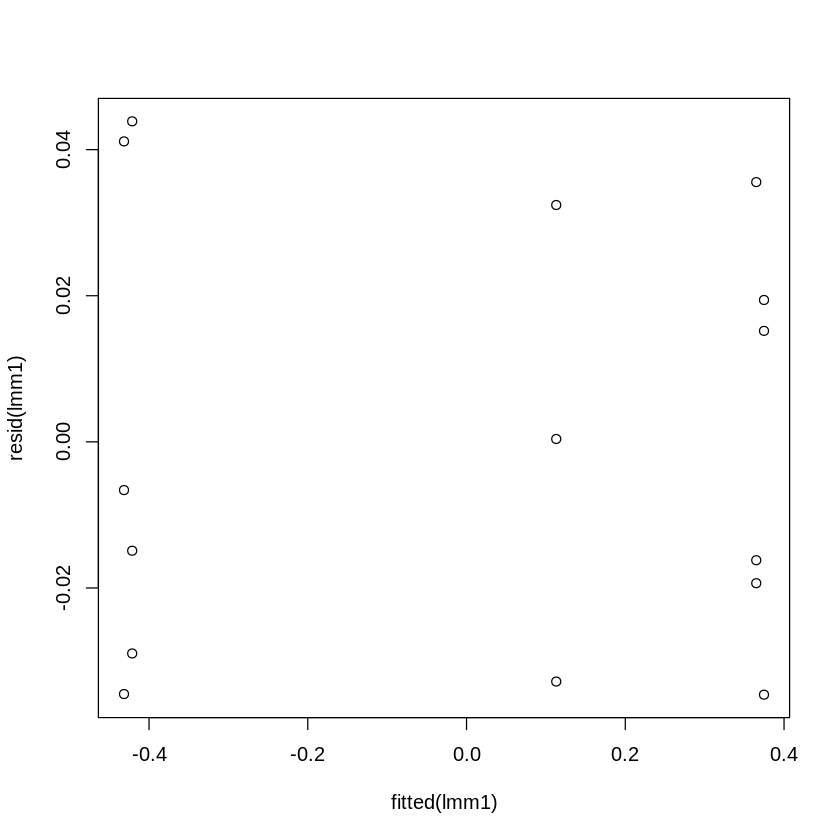

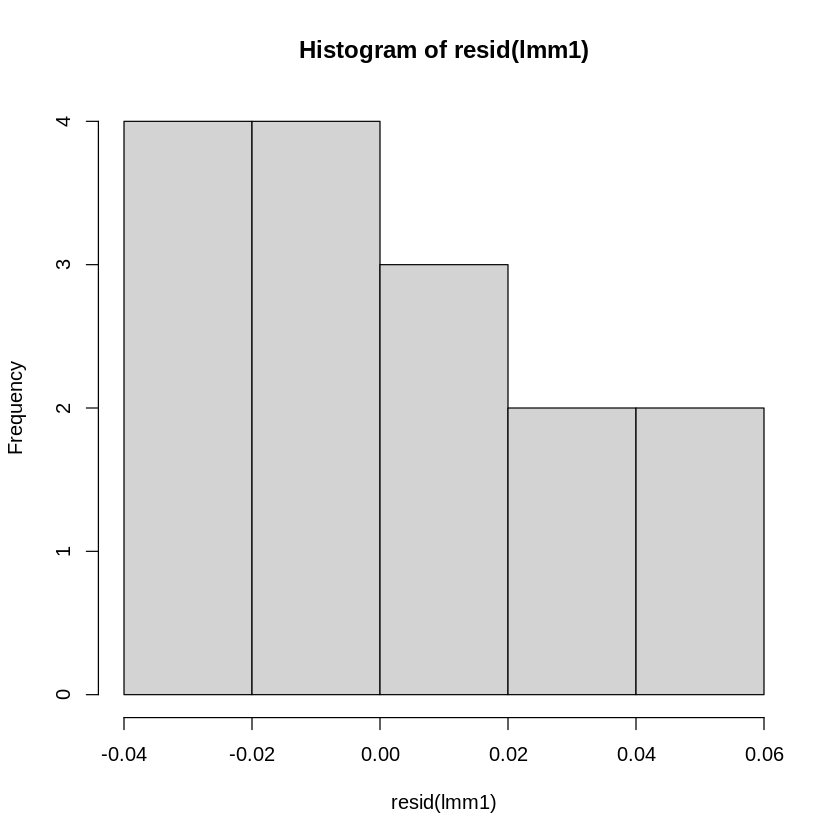

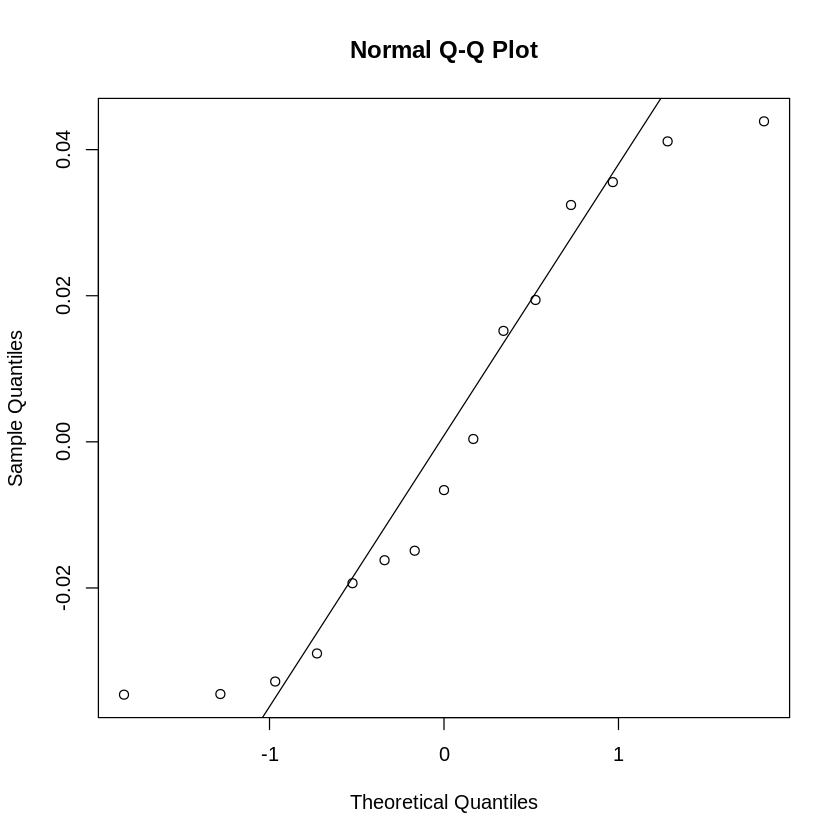

In [199]:
# Model: PCoA1 (Fixed effects: Pore size and Sampling Order; Random effect: Replicate)
lmm1 <- lmer(PCoA1 ~ PoreSize + SamplingOrder + (1|Replicate), data = coords)
summary(lmm1)
plot(resid(lmm1) ~ fitted(lmm1))
hist(resid(lmm1))
qqnorm(resid(lmm1)); qqline(resid(lmm1))

The replicate explains almost no variance, we should consider this values as a zero. We see again the effect of the smalle pore sizes differing to the others.
We do not obtained variance per replicated becausae of the low number of replicates.

In [200]:
lmer(PCoA1 ~ PoreSize + (1|SamplingOrder), data = coords)

boundary (singular) fit: see help('isSingular')



Linear mixed model fit by REML ['lmerMod']
Formula: PCoA1 ~ PoreSize + (1 | SamplingOrder)
   Data: coords
REML criterion at convergence: -38.8245
Random effects:
 Groups        Name        Std.Dev.
 SamplingOrder (Intercept) 0.00000 
 Residual                  0.03288 
Number of obs: 15, groups:  SamplingOrder, 5
Fixed Effects:
(Intercept)  PoreSize1.2  PoreSize5.0  PoreSize8.0  
     0.3699      -0.2569      -0.7911      -0.8014  
optimizer (nloptwrap) convergence code: 0 (OK) ; 0 optimizer warnings; 1 lme4 warnings 